In [1]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

<h3>CMS pileup data compression based on VQ-VAE compression</h3>

Experiment comments and insights:
* Codebook entries from 256 vectors (rows), only approximately 120 codebook entries are used effectively based perplexity
* Reconstruction improves with bigger latent vector and num embeddings. Reducing codebook size, improves usage but not reconstruction quality
* Validation set properly works with higher beta coeficient roughly from beta in [0.2, 0.31]
* Codebook plots describe codebook variation, whether certain weights are mostly zero (grey color) and are codebook usage is not sparse (orange colors)
* Average perplexity is very high. Model is able to learn meaningfull representations

Utility function import and prepearation

In [3]:
from helpers.model_tool import ModelTool
from helpers.data_tool import CMSDataTool, \
                                CMSPlots, \
                                PixelPatchesDataset

<h3>Helper objects</h3>

In [4]:
model_tool = ModelTool()
cms_data_tool = CMSDataTool()
cms_plots = CMSPlots()

<h3>Helper constants</h3>

In [5]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25 
LOG_EVERY = 15

<h3>Data loading</h3>

In [6]:
# Loading data
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 243.15it/s]


<h3>VQ-VAE Hyperparameters</h3>

In [7]:
batch_size = 64
beta = 0.31
# beta = 0.98

# beta = 1 0.
# beta is possible in interval [4e-3, 8e-3]

# 0.1, 0.08 - on the right track

learning_rate = 1e-3
model_param_scale = 5
# model_param_scale = 1 (right order)
# learning_rate = 1e-3 (right on track)

num_epochs = 80
# num_epochs = 1

# input channels
channels = 1 # since grayscale images are used, we go with 1 channel images
hidden_channels = 64

# how many codebook entries
num_embeddings = 256
# num_embeddings = 32 (on track)

latent_dim = 32
# latent_dim = 64 (on track)

# Residual layer config
residual_channels = 32
residual_layers = 2


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [9]:
mse = MeanSquaredError()
mse = mse.to(device)

In [10]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [11]:
event_train = events_train[:SELECTED_EVENTS][0]

In [12]:
patch_amount = cms_data_tool._get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


<h3>Data preprocessing</h3>

<h3>Data loading</h3>

In [13]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, PATCH_SIZE, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.02 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 12685
Validation set size: 317
Test set size: 2855


<h3>VAE Binary Cross Entropy loss for VQ-VAE</h3>

In [14]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor
) -> float:
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    return recon_loss

<h3>VQ-VAE model</h3>

In [15]:
# Goal of Vector Quantization is to solve posterior collapse problem

class VectorQuantizer(nn.Module):
    """
    Discretization bottleneck part of the VQ-VAE.

    Inputs:
    - n_e : number of embeddings
    - e_dim : dimension of embedding
    - beta : commitment cost used in loss term, beta * ||z_e(x)-sg[e]||^2
    """

    def __init__(self, n_e, e_dim, beta):
        super(VectorQuantizer, self).__init__()
        self.n_e = n_e
        self.e_dim = e_dim
        self.beta = beta

        self.embedding = nn.Embedding(self.n_e, self.e_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.n_e, 1.0 / self.n_e)

    def forward(self, z):
        """
        Inputs the output of the encoder network z and maps it to a discrete
        one-hot vector that is the index of the closest embedding vector e_j

        z (continuous) -> z_q (discrete)

        z.shape = (batch, channel, height, width)

        quantization pipeline:

            1. get encoder input (B,C,H,W)
            2. flatten input to (B*H*W,C)

        """
        # reshape z -> (batch, height, width, channel) and flatten
        z = z.permute(0, 2, 3, 1).contiguous()
        z_flattened = z.view(-1, self.e_dim)
        # distances from z to embeddings e_j (z - e)^2 = z^2 + e^2 - 2 e * z

        # NOTE: is a matrix learnable vector for learning codebook indices. 
        codebook = self.embedding.weight
        
        # Euclidean distance for finding closest codebooks
        d = torch.sum(z_flattened ** 2, dim=1, keepdim=True) + \
            torch.sum(self.embedding.weight**2, dim=1) - 2 * \
            torch.matmul(z_flattened, codebook.t())
            
        # Result -> d gets dimensions from matrix torch.matmul(z_flattened, self.embedding.weight.t())
        # embedding weight t is defined by num_embeddings, latent_dim
        # --------------------
            
        # find closest encodings
        min_encoding_indices = torch.argmin(d, dim=1).unsqueeze(1)
        min_encodings = torch.zeros(
            min_encoding_indices.shape[0], self.n_e).to(device)
        
        # perform one hot encoding
        min_encodings.scatter_(1, min_encoding_indices, 1)

        # NOTE: selects weights form embedding weight and puts them based on one hot encoding
        z_q = torch.matmul(min_encodings, codebook).view(z.shape)
        
        # beta - commitment cost used in loss term
        
        # compute loss for embedding
        loss = torch.mean((z_q.detach() - z)**2) + self.beta * \
            torch.mean((z_q - z.detach()) ** 2)

        # preserve gradients with preservation trick. Allows gradients to exist
        # (z_q - z.detach() )- is like a constant

        # We make quantized latent space vector to get closer to the encoder output
        # we highliht the codewords and gradually each epoch we force neaigoboring pixels
        # to be associating with cendroids
        z_q = z + (z_q - z).detach()

        # perplexity - average of weights of probabilities
        e_mean = torch.mean(min_encodings, dim=0)
        
        # Measures how many codebook vectors are beeing used
        perplexity = torch.exp(-torch.sum(e_mean * torch.log(e_mean + 1e-10)))

        # reshape back to match original input shape
        # contiguous() is used for improving performance
        z_q = z_q.permute(0, 3, 1, 2).contiguous()

        return loss, z_q, perplexity, min_encodings, min_encoding_indices, codebook

In [16]:
class ResidualLayer(nn.Module):
    """
    One residual layer inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    """

    def __init__(self, in_dim, h_dim, res_h_dim, slope):
        super(ResidualLayer, self).__init__()
        self.res_block = nn.Sequential(
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(in_dim, res_h_dim, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(res_h_dim, h_dim, kernel_size=1,
                      stride=1, bias=False)
        )

    def forward(self, x):
        x = x + self.res_block(x)
        return x


class ResidualStack(nn.Module):
    """
    A stack of residual layers inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack
    """

    def __init__(self, in_dim, h_dim, res_h_dim, n_res_layers, slope):
        super(ResidualStack, self).__init__()
        self.n_res_layers = n_res_layers
        self.slope = slope
        self.stack = nn.ModuleList(
            [
                ResidualLayer(in_dim, h_dim, res_h_dim, slope)
                for _ in range(n_res_layers)
            ])

    def forward(self, x):
        for layer in self.stack:
            x = layer(x)
        x = F.relu(x)
        return x

In [17]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VQVAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float,
        res_h_dim: int,
        n_res_layers: int,
        residual_slope: float = 0.08
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(   
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, latent_dim),
            ResidualStack(latent_dim, latent_dim, res_h_dim, n_res_layers, residual_slope)
        )
        
        self.vq_layer = VectorQuantizer(num_embeddings, latent_dim, beta)
        
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            ResidualStack(hidden_channels * 2, hidden_channels * 2, res_h_dim, n_res_layers, residual_slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )

        
    def forward(self, x):
        z_encoded = self.encoder(x)
        
        (
            recon_loss, 
            z_q, 
            perplexity, 
            min_encodings, 
            min_encoding_indices, 
            codebook
        ) = self.vq_layer(z_encoded)
        
        output = self.decoder(z_q)
        
        return (
            output, 
            codebook, 
            z_q,
            perplexity, 
            recon_loss 
        )

In [18]:
model = VQVAE(
    hidden_channels=hidden_channels, 
    kernel_size = 4,
    slope=0.1,
    n_res_layers=residual_layers, # residual hidden layers
    res_h_dim=residual_channels # residual hidden channels
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

<h3>VQ-VAE training loop</h3>

Epoch 1/80: 100%|██████████| 199/199 [00:00<00:00, 280.08it/s, Loss (BCE + VQ)=0.0665]


Epoch [1/80] summary:Average Loss: VQ + BCE = 0.1823,  Average loss: BCE = 0.0734 MSE = 0.009412579053554254 avg_perplexity = 8.795480609539165
Average validation set BCE loss: 0.05454549044370651
Before compression (Training)
Shape: (13, 8, 8)


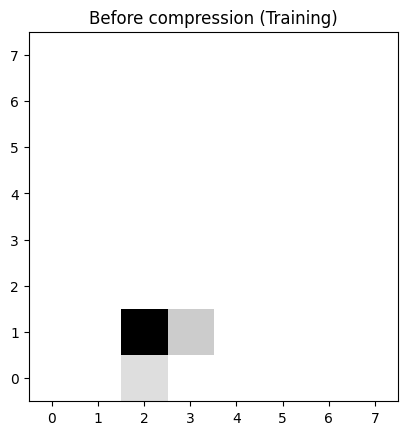

After compression (Training)
Shape: (1, 8, 8)


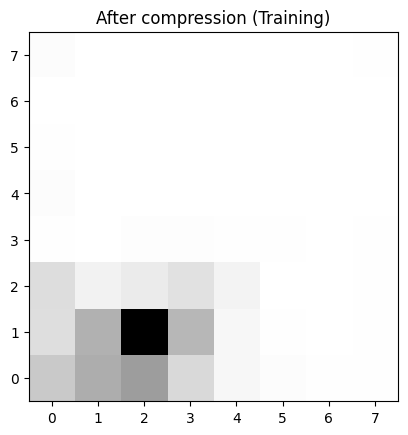

Epoch 2/80: 100%|██████████| 199/199 [00:00<00:00, 372.54it/s, Loss (BCE + VQ)=0.0365]


Epoch [2/80] summary:Average Loss: VQ + BCE = 0.0547,  Average loss: BCE = 0.0466 MSE = 0.004619776760344979 avg_perplexity = 24.253414120506402
Average validation set BCE loss: 0.04589628949761391


Epoch 3/80: 100%|██████████| 199/199 [00:00<00:00, 374.70it/s, Loss (BCE + VQ)=0.0503]


Epoch [3/80] summary:Average Loss: VQ + BCE = 0.0473,  Average loss: BCE = 0.0417 MSE = 0.003825206134056476 avg_perplexity = 32.80397405576466
Average validation set BCE loss: 0.042412468791008


Epoch 4/80: 100%|██████████| 199/199 [00:00<00:00, 388.20it/s, Loss (BCE + VQ)=0.0458]


...

Epoch [14/80] summary:Average Loss: VQ + BCE = 0.0376,  Average loss: BCE = 0.0339 MSE = 0.0024342846433075154 avg_perplexity = 56.63423141402815
Average validation set BCE loss: 0.03715909793972969


Epoch 15/80: 100%|██████████| 199/199 [00:00<00:00, 386.28it/s, Loss (BCE + VQ)=0.0426]


Epoch [15/80] summary:Average Loss: VQ + BCE = 0.0376,  Average loss: BCE = 0.0338 MSE = 0.002416880416389012 avg_perplexity = 57.163829420080134
Average validation set BCE loss: 0.03646654412150383


Epoch 16/80: 100%|██████████| 199/199 [00:00<00:00, 368.59it/s, Loss (BCE + VQ)=0.0343]


Epoch [16/80] summary:Average Loss: VQ + BCE = 0.0371,  Average loss: BCE = 0.0335 MSE = 0.0023446597185818917 avg_perplexity = 57.18470858089888
Average validation set BCE loss: 0.03700646385550499
Before compression (Training)
Shape: (13, 8, 8)


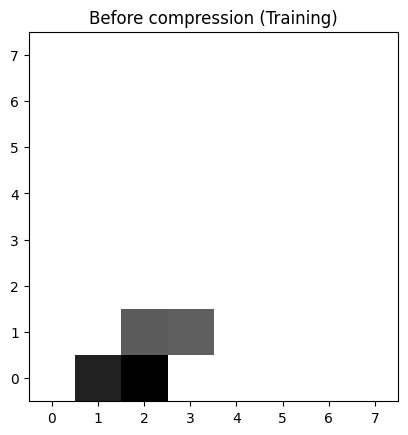

After compression (Training)
Shape: (1, 8, 8)


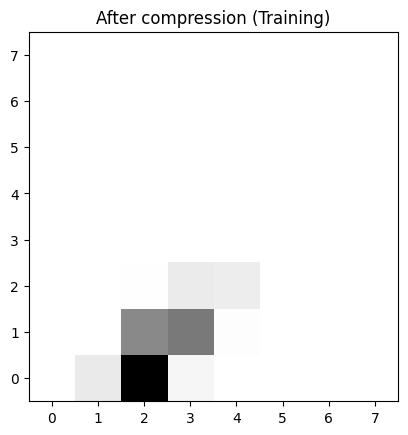

Epoch 17/80: 100%|██████████| 199/199 [00:00<00:00, 378.22it/s, Loss (BCE + VQ)=0.0315]


Epoch [17/80] summary:Average Loss: VQ + BCE = 0.0367,  Average loss: BCE = 0.0332 MSE = 0.0022880340705218553 avg_perplexity = 57.489544461120914
Average validation set BCE loss: 0.03707894682884216


Epoch 18/80: 100%|██████████| 199/199 [00:00<00:00, 379.07it/s, Loss (BCE + VQ)=0.0385]


Epoch [18/80] summary:Average Loss: VQ + BCE = 0.0366,  Average loss: BCE = 0.0331 MSE = 0.0022541903048267017 avg_perplexity = 58.58080730725772
Average validation set BCE loss: 0.036679011583328244


Epoch 19/80: 100%|██████████| 199/199 [00:00<00:00, 373.73it/s, Loss (BCE + VQ)=0.0236]


...

Epoch [29/80] summary:Average Loss: VQ + BCE = 0.0346,  Average loss: BCE = 0.0316 MSE = 0.0019172929811183757 avg_perplexity = 61.10568080116157
Average validation set BCE loss: 0.036361537873744965


Epoch 30/80: 100%|██████████| 199/199 [00:00<00:00, 369.30it/s, Loss (BCE + VQ)=0.0468]


Epoch [30/80] summary:Average Loss: VQ + BCE = 0.0345,  Average loss: BCE = 0.0315 MSE = 0.001887487530727033 avg_perplexity = 61.716198619286615
Average validation set BCE loss: 0.036235639452934267


Epoch 31/80: 100%|██████████| 199/199 [00:00<00:00, 366.73it/s, Loss (BCE + VQ)=0.0567]


Epoch [31/80] summary:Average Loss: VQ + BCE = 0.0347,  Average loss: BCE = 0.0316 MSE = 0.00191200345967564 avg_perplexity = 61.770926595333236
Average validation set BCE loss: 0.03567819371819496
Before compression (Training)
Shape: (13, 8, 8)


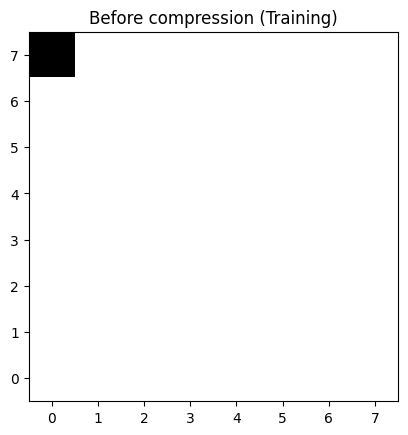

After compression (Training)
Shape: (1, 8, 8)


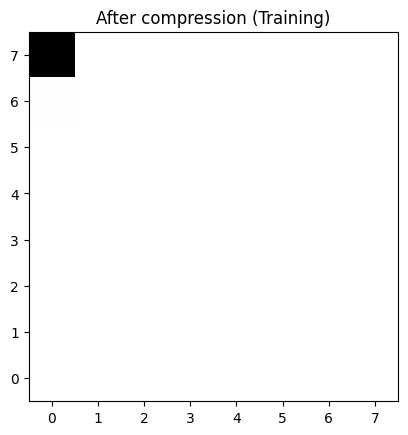

Epoch 32/80: 100%|██████████| 199/199 [00:00<00:00, 369.31it/s, Loss (BCE + VQ)=0.0401]


Epoch [32/80] summary:Average Loss: VQ + BCE = 0.0345,  Average loss: BCE = 0.0314 MSE = 0.0018759997954695068 avg_perplexity = 61.591152804580766
Average validation set BCE loss: 0.036032737046480176


Epoch 33/80: 100%|██████████| 199/199 [00:00<00:00, 365.45it/s, Loss (BCE + VQ)=0.0334]


Epoch [33/80] summary:Average Loss: VQ + BCE = 0.0343,  Average loss: BCE = 0.0313 MSE = 0.0018480800188160572 avg_perplexity = 61.744335586701204
Average validation set BCE loss: 0.036442623287439344


Epoch 34/80: 100%|██████████| 199/199 [00:00<00:00, 368.16it/s, Loss (BCE + VQ)=0.0265]


...

Epoch [44/80] summary:Average Loss: VQ + BCE = 0.0332,  Average loss: BCE = 0.0305 MSE = 0.001614459012529752 avg_perplexity = 63.54959080566713
Average validation set BCE loss: 0.035325844585895536


Epoch 45/80: 100%|██████████| 199/199 [00:00<00:00, 389.55it/s, Loss (BCE + VQ)=0.0311]


Epoch [45/80] summary:Average Loss: VQ + BCE = 0.0330,  Average loss: BCE = 0.0303 MSE = 0.001538996572720926 avg_perplexity = 63.600640474252366
Average validation set BCE loss: 0.03534264639019966


Epoch 46/80: 100%|██████████| 199/199 [00:00<00:00, 383.61it/s, Loss (BCE + VQ)=0.0287]


Epoch [46/80] summary:Average Loss: VQ + BCE = 0.0328,  Average loss: BCE = 0.0302 MSE = 0.0015124332410723308 avg_perplexity = 63.50801218694179
Average validation set BCE loss: 0.03569334149360657
Before compression (Training)
Shape: (13, 8, 8)


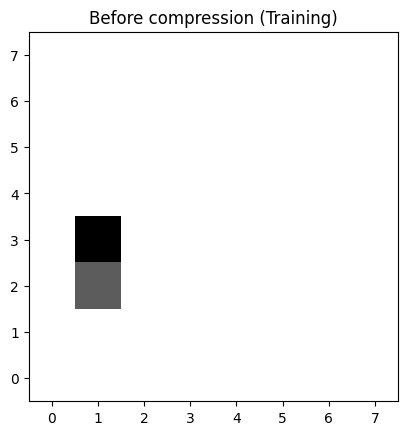

After compression (Training)
Shape: (1, 8, 8)


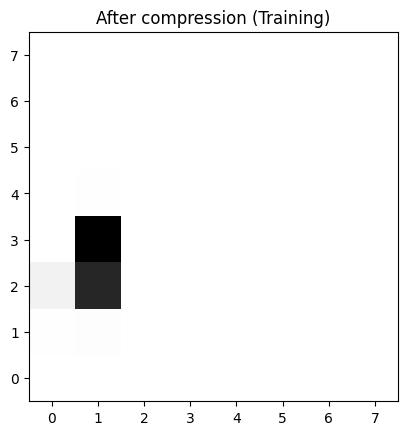

Epoch 47/80: 100%|██████████| 199/199 [00:00<00:00, 360.08it/s, Loss (BCE + VQ)=0.0365]


Epoch [47/80] summary:Average Loss: VQ + BCE = 0.0329,  Average loss: BCE = 0.0302 MSE = 0.0015218152761712071 avg_perplexity = 63.863720352326204
Average validation set BCE loss: 0.03632114455103874


Epoch 48/80: 100%|██████████| 199/199 [00:00<00:00, 376.19it/s, Loss (BCE + VQ)=0.0344]


Epoch [48/80] summary:Average Loss: VQ + BCE = 0.0327,  Average loss: BCE = 0.0301 MSE = 0.0014757033660961082 avg_perplexity = 63.91608658987074
Average validation set BCE loss: 0.035622114688158034


Epoch 49/80: 100%|██████████| 199/199 [00:00<00:00, 376.46it/s, Loss (BCE + VQ)=0.0397]


...

Epoch [59/80] summary:Average Loss: VQ + BCE = 0.0319,  Average loss: BCE = 0.0295 MSE = 0.001298619185319292 avg_perplexity = 64.31176123307579
Average validation set BCE loss: 0.03543146997690201


Epoch 60/80: 100%|██████████| 199/199 [00:00<00:00, 373.90it/s, Loss (BCE + VQ)=0.0348]


Epoch [60/80] summary:Average Loss: VQ + BCE = 0.0319,  Average loss: BCE = 0.0295 MSE = 0.0012945792156309076 avg_perplexity = 64.2152550472087
Average validation set BCE loss: 0.035408339276909825


Epoch 61/80: 100%|██████████| 199/199 [00:00<00:00, 365.66it/s, Loss (BCE + VQ)=0.0285]


Epoch [61/80] summary:Average Loss: VQ + BCE = 0.0318,  Average loss: BCE = 0.0294 MSE = 0.0012997537509107672 avg_perplexity = 64.49839100286589
Average validation set BCE loss: 0.03575039952993393
Before compression (Training)
Shape: (13, 8, 8)


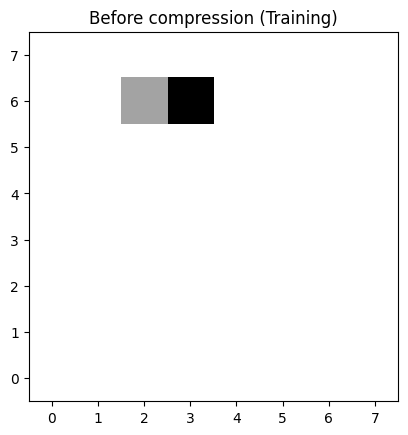

After compression (Training)
Shape: (1, 8, 8)


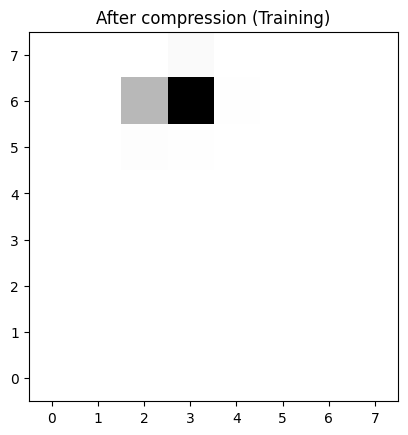

Epoch 62/80: 100%|██████████| 199/199 [00:00<00:00, 342.67it/s, Loss (BCE + VQ)=0.0296]


Epoch [62/80] summary:Average Loss: VQ + BCE = 0.0318,  Average loss: BCE = 0.0294 MSE = 0.0013004215211892996 avg_perplexity = 64.26206485230719
Average validation set BCE loss: 0.035836216807365415


Epoch 63/80: 100%|██████████| 199/199 [00:00<00:00, 373.51it/s, Loss (BCE + VQ)=0.0289]


Epoch [63/80] summary:Average Loss: VQ + BCE = 0.0317,  Average loss: BCE = 0.0294 MSE = 0.001265316658732879 avg_perplexity = 64.04792344749872
Average validation set BCE loss: 0.03546036928892136


Epoch 64/80: 100%|██████████| 199/199 [00:00<00:00, 373.49it/s, Loss (BCE + VQ)=0.028] 


...

Epoch [74/80] summary:Average Loss: VQ + BCE = 0.0311,  Average loss: BCE = 0.0289 MSE = 0.001141263775752118 avg_perplexity = 65.16659967623764
Average validation set BCE loss: 0.03634538948535919


Epoch 75/80: 100%|██████████| 199/199 [00:00<00:00, 379.55it/s, Loss (BCE + VQ)=0.0321]


Epoch [75/80] summary:Average Loss: VQ + BCE = 0.0311,  Average loss: BCE = 0.0289 MSE = 0.0011136345217243099 avg_perplexity = 65.49366645237909
Average validation set BCE loss: 0.035664152354002


Epoch 76/80: 100%|██████████| 199/199 [00:00<00:00, 362.06it/s, Loss (BCE + VQ)=0.0295]


Epoch [76/80] summary:Average Loss: VQ + BCE = 0.0310,  Average loss: BCE = 0.0289 MSE = 0.0011206570323603461 avg_perplexity = 65.51459313397432
Average validation set BCE loss: 0.036326130479574205
Before compression (Training)
Shape: (13, 8, 8)


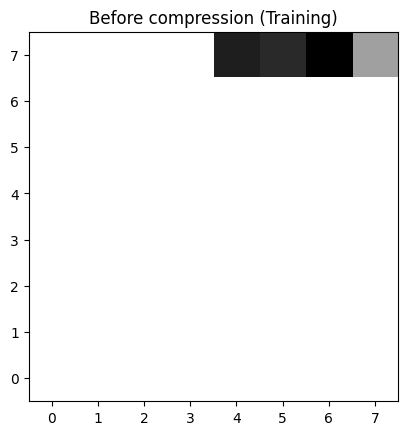

After compression (Training)
Shape: (1, 8, 8)


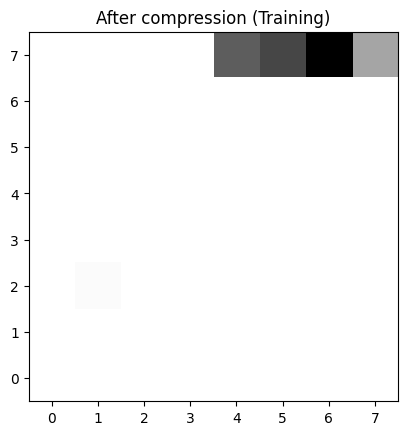

Epoch 77/80: 100%|██████████| 199/199 [00:00<00:00, 369.80it/s, Loss (BCE + VQ)=0.0358]


Epoch [77/80] summary:Average Loss: VQ + BCE = 0.0309,  Average loss: BCE = 0.0288 MSE = 0.0010763808714001248 avg_perplexity = 65.88197552858286
Average validation set BCE loss: 0.03570195138454437


Epoch 78/80: 100%|██████████| 199/199 [00:00<00:00, 373.92it/s, Loss (BCE + VQ)=0.0245]


Epoch [78/80] summary:Average Loss: VQ + BCE = 0.0309,  Average loss: BCE = 0.0288 MSE = 0.0011021168914216398 avg_perplexity = 66.05870909187662
Average validation set BCE loss: 0.03608586043119431


Epoch 79/80: 100%|██████████| 199/199 [00:00<00:00, 366.92it/s, Loss (BCE + VQ)=0.0433]


Epoch [79/80] summary:Average Loss: VQ + BCE = 0.0310,  Average loss: BCE = 0.0288 MSE = 0.001090789677682871 avg_perplexity = 66.02300295039038
Average validation set BCE loss: 0.03565324693918228


Epoch 80/80: 100%|██████████| 199/199 [00:00<00:00, 373.46it/s, Loss (BCE + VQ)=0.0406]


Epoch [80/80] summary:Average Loss: VQ + BCE = 0.0310,  Average loss: BCE = 0.0288 MSE = 0.001084862421114634 avg_perplexity = 66.01762434226184
Average validation set BCE loss: 0.03619207590818405
Before compression (Validation)
Shape: (64, 8, 8)


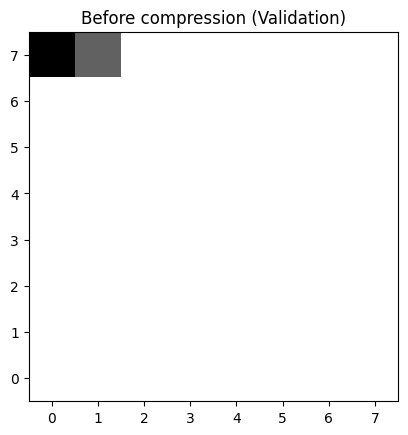

After compression (Validation)
Shape: (1, 8, 8)


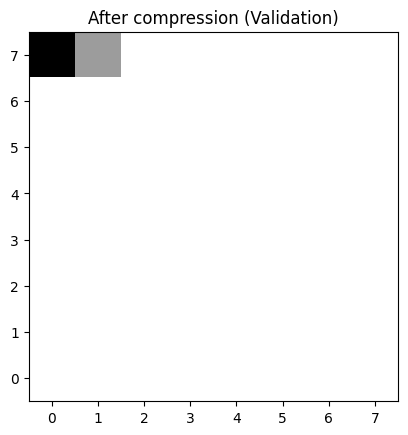

----------------------------------------
Patch = 0 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 1.7661116578255367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 43.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


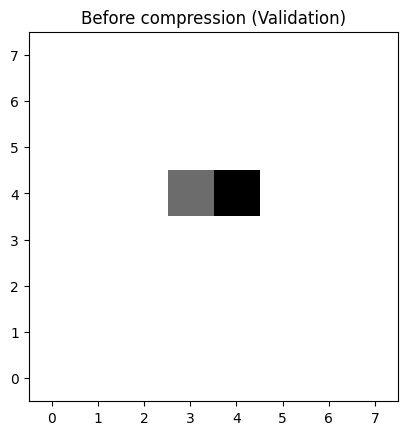

After compression (Validation)
Shape: (1, 8, 8)


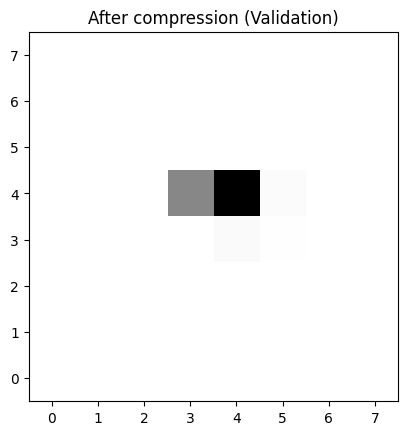

----------------------------------------
Patch = 1 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 1.7661116578255367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 43.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


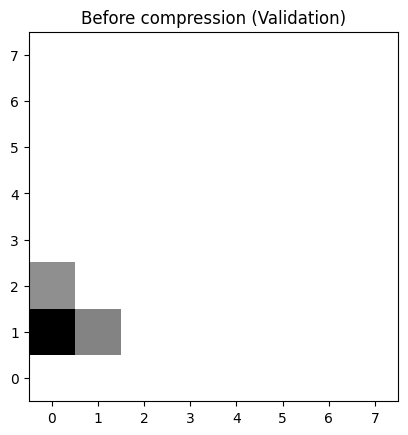

After compression (Validation)
Shape: (1, 8, 8)


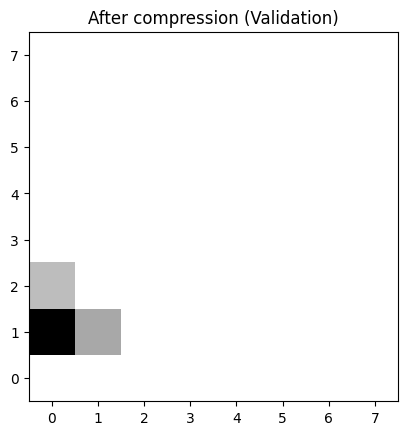

----------------------------------------
Patch = 2 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 1.7661116578255367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 43.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


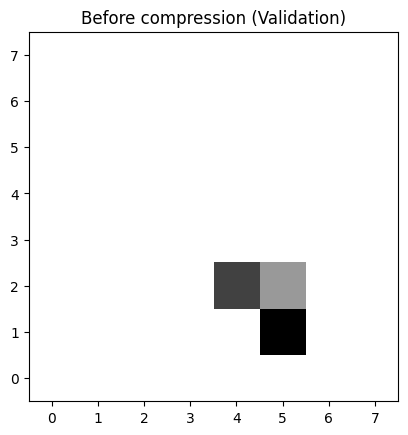

After compression (Validation)
Shape: (1, 8, 8)


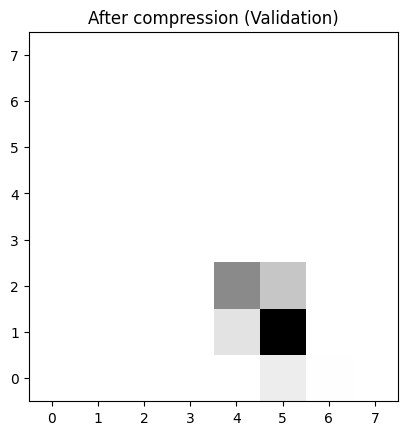

----------------------------------------
Patch = 3 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 1.7661116578255367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 43.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (61, 8, 8)


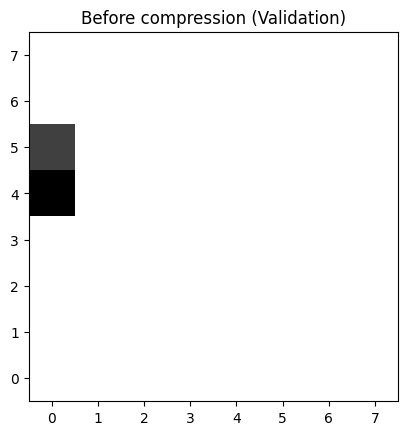

After compression (Validation)
Shape: (1, 8, 8)


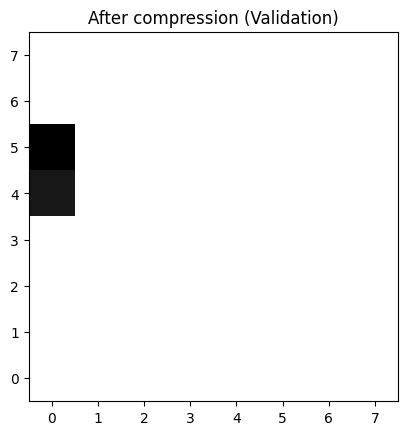

----------------------------------------
Patch = 4 compression results
----------------------------------------
Patch encoder output dimensions:(w x h) = (2) x (2)
Compression ratio = 1.7661116578255367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 43.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Saving trained model VQ-VAE


In [19]:
# BCE loss average values
average_loss_train = []
average_loss_values_val = []
average_loss_train_bce = []

# Patches (validation)
patches_before_val = []
patches_after_val = []
patches_encodings_val = [] # latent vector
patches_pairs_val = []

# Patches (training)
patches_before_train = []
patches_encodings_train = []
patches_after_train = []

# MSE residual averages
average_loss_train_mse = []
average_loss_valid_mse_val = []

# perplexity
average_perplexity_train = []
average_perplexity_val = []

plot_val_patches_limit = 25


for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_loss_bce = 0
    train_loss_mse = 0
    train_perplexity = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)
        
        (
            recon_patch, 
            codebook_train,
            _,
            perplexity,
            vq_loss
        ) = model(
           X_adcs
        )
        
        
        bce_loss = _get_vae_loss(recon_patch, X_adcs)
        total_vq_loss = bce_loss + vq_loss
        
        recon_patch_train = recon_patch.float().to(device)      
        train_loss += total_vq_loss.item()
        train_loss_bce += bce_loss.item()
        
        total_vq_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=model_param_scale)
            
        train_loss_mse += mse(recon_patch_train, X_adcs).item()
        train_perplexity += perplexity.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss (BCE + VQ)': total_vq_loss.item()})
        # scheduler.step()
        
        
    avg_loss_bce_vq = train_loss / len(train_loader)
    avg_loss_mse = train_loss_mse / len(train_loader)
    avg_perplexity = train_perplexity / len(train_loader)
    avg_loss_bce = train_loss_bce / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] summary:"
        f"Average Loss: VQ + BCE = {avg_loss_bce_vq:.4f}, ",
        f"Average loss: BCE = {avg_loss_bce:.4f}",
        f"MSE = {avg_loss_mse}",
        f"avg_perplexity = {avg_perplexity}"
    )
    
    average_loss_train.append(avg_loss_bce_vq)
    average_loss_train_mse.append(avg_loss_mse)
    average_perplexity_train.append(avg_perplexity)
    average_loss_train_bce.append(avg_loss_bce)
    
    # Test with validation set for checking error residuals
    with torch.no_grad():
        model.eval()
        total_bce_loss_val = 0
        total_mse_loss_val = 0
        
        # Calculating average erros 
        for patch_val in val_loader:
            patch_val = patch_val.to(device)  
            
            (
               recon_patch_val, 
               codebook_val, 
               z_q_val,
               perplexity_val,
               _,
            ) = model(patch_val)
            
            patch_bce_val = F.binary_cross_entropy(
                recon_patch_val,
                patch_val,
                reduction="mean"
            ).cpu().detach().numpy().item()
            total_bce_loss_val += patch_bce_val
            
            patch_mse_val = mse(
               patch_val,
               recon_patch_val  
            ).item()
            total_mse_loss_val += patch_mse_val
            
        average_loss_val = total_bce_loss_val / len(val_loader)
        average_loss_val_mse = total_mse_loss_val / len(val_loader)
        average_loss_values_val.append(average_loss_val)
        average_loss_valid_mse_val.append(average_loss_val_mse)
        
        print(f"Average validation set BCE loss: {average_loss_val}")
        # print("Last batch patch, compression metrics:")
        # for k, v in result.items():
        #     print(f"{k} = {v}")
    
        # Test with validation set for checking image reconstruction quality
    
        if epoch % LOG_EVERY == 0:
                # selecting events before reconstruction using one test loader as validation
                # plotting last training
                
                print("Before compression (Training)")                    
                X_adcs_ts = model_tool._tensor_to_numpy(
                    X_adcs.squeeze(1)
                )
                
                print(f"Shape: {X_adcs_ts.shape}")            
                cms_plots.plot_patch(X_adcs_ts[0], "Before compression (Training)")
                
                recon_patch_train_np = model_tool._tensor_to_numpy(
                    recon_patch_train[0]
                )
                print("After compression (Training)")
                print(f"Shape: {recon_patch_train_np.shape}")
                
                cms_plots.plot_patch(recon_patch_train_np[0], "After compression (Training)")
                
                if len(patches_after_train) < plot_val_patches_limit:
                    patches_before_train.append(X_adcs_ts[0])
                    patches_after_train.append(recon_patch_train_np[0])
                    patches_encodings_train.append(
                        model_tool._tensor_to_numpy(codebook_train)
                    )
                
        if epoch == num_epochs - 1:
            for (plot_idx, patch_val) in enumerate(val_loader):
                patch_val = patch_val.to(device)           
                patch_val = patch_val.float()
                (
                    recon_patch_val, 
                    codebook_val, 
                    z_q_val, 
                    perplexity_val,
                    _
                ) = model(patch_val)
                
                print("Before compression (Validation)")                    
                patch_val_ts_val = model_tool._tensor_to_numpy(
                    patch_val.squeeze(1)
                )
                
                print(f"Shape: {patch_val_ts_val.shape}")            
                cms_plots.plot_patch(patch_val_ts_val[0], "Before compression (Validation)")
                
                patches_before_val.append(patch_val_ts_val[0])
                
                recon_patch_np_val = model_tool._tensor_to_numpy(
                    recon_patch_val[0]
                )
                print("After compression (Validation)")
                print(f"Shape: {recon_patch_np_val.shape}")
                
                cms_plots.plot_patch(
                    recon_patch_np_val[0], 
                    "After compression (Validation)"
                )
            
                patches_after_val.append(recon_patch_np_val[0])  
                encodings_val_np = model_tool._tensor_to_numpy(codebook_val)
                patches_encodings_val.append(encodings_val_np) 
                
                width_val, height_val = z_q_val[0][0].shape
                c_width, c_height = codebook_val.shape
                
                print("----------------------------------------")
                print(f"Patch = {plot_idx} compression results")
                print("----------------------------------------")
                print(
                    f"Patch encoder output dimensions:"
                    f"(w x h) = ({width_val}) x ({height_val})"
                )
                
                compression_ratio = cms_data_tool._get_compression_ratio(
                    n_hits_total=total_hit_amount,
                    patch_amount=patch_amount,
                    encoded_patch_size=(width_val, height_val, num_embeddings),
                    patch_size=PATCH_SIZE
                )
                total_bits = cms_data_tool._get_total_hit_bits(total_hit_amount)
                encoded_patch_bits = cms_data_tool._get_encoded_patch_bits(
                    (
                        width_val, 
                        height_val, 
                        num_embeddings
                    ), 
                    PATCH_SIZE
                )
                
                print(f"Compression ratio = {compression_ratio}")
                print(f"total_hit_amount = {total_hit_amount}")
                print(f"total_hit_bits = {total_bits}")
                print(f"patch_amount = {patch_amount}")
                print(f"encoded_patch_bits = {encoded_patch_bits} (1 patch {PATCH_SIZE} x {PATCH_SIZE})")
                print(f"num_embeddings = {num_embeddings}")
                print(f"Codebook dimensions: {c_width} x {c_height}")
                print("----------------------------------------")
            
# save model
print("Saving trained model VQ-VAE")
torch.save(model.state_dict(), "../bin/vqvae.pth")

<h3>VQ-VAE results analysis</h3>

In [20]:
total_bits = cms_data_tool._get_total_hit_bits(
    total_hit_amount
)


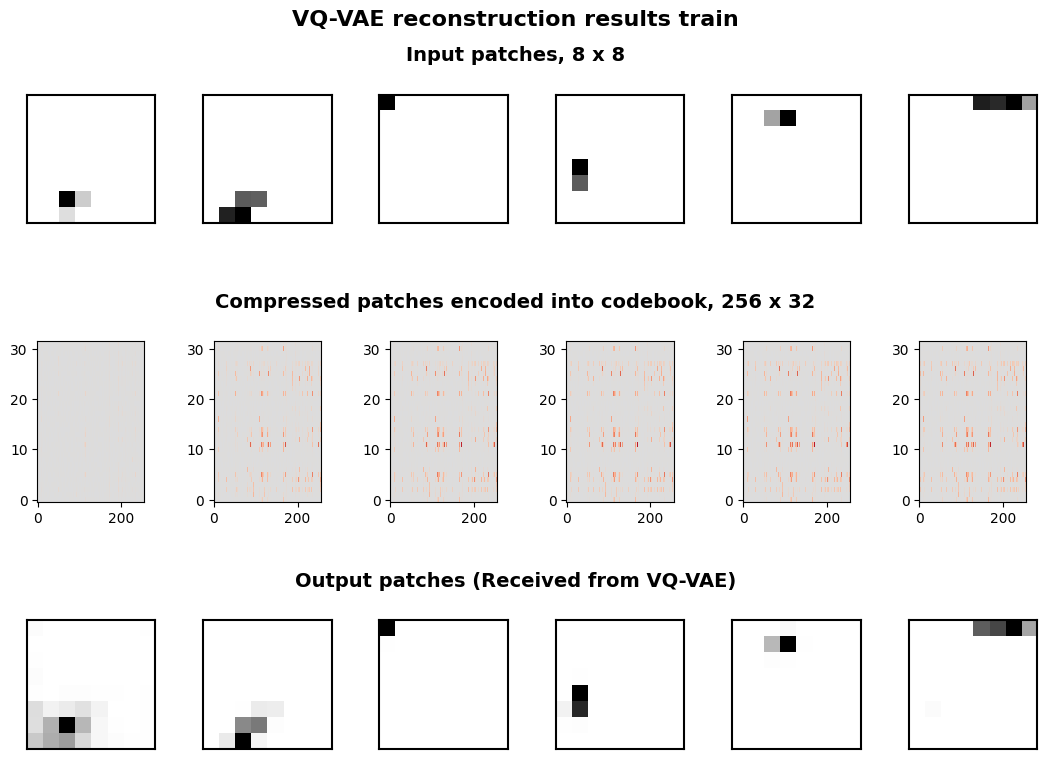

In [21]:
patch_rows = [
    (patches_before_train, "Input patches, 8 x 8"),
    (
        patches_encodings_train, 
        f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
    ),
    (patches_after_train, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results train", include_codebook=True)

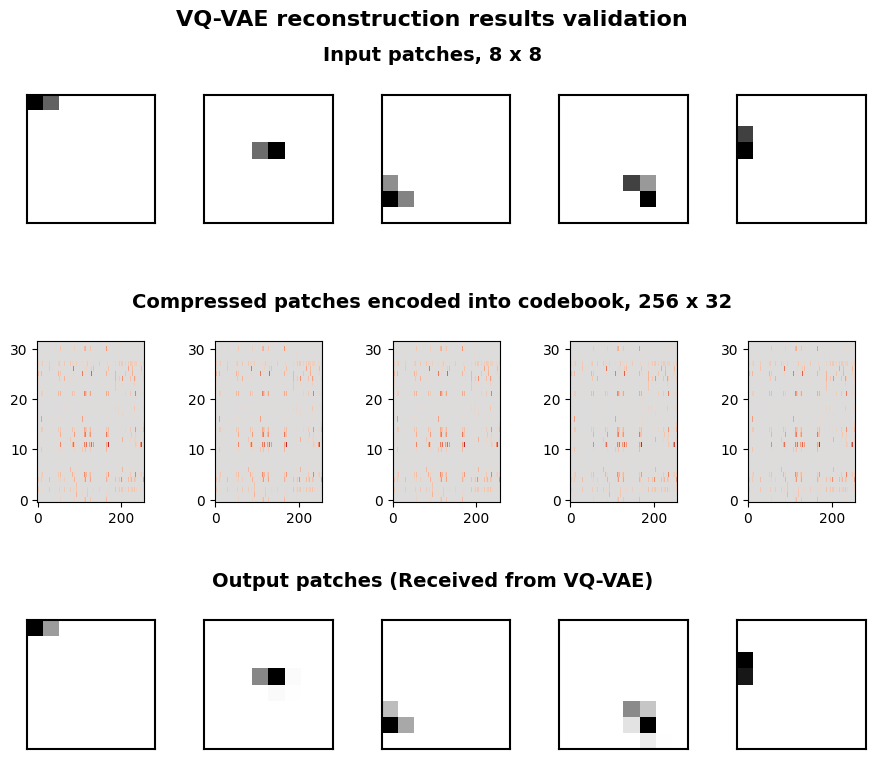

In [22]:
patch_rows = [
    (patches_before_val, "Input patches, 8 x 8"),
    (patches_encodings_val, 
     f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
     ),
    (patches_after_val, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(
    patch_rows, 
    "VQ-VAE reconstruction results validation",
    include_codebook=True
)

In [23]:
# TODO
# Improve gradients
model_tool._display_gradients(model)

Showing model gradients
encoder.0.weight 0.0525386668741703
encoder.1.weight 0.004485068377107382
encoder.1.bias 0.013100672513246536
encoder.3.weight 0.06896304339170456
encoder.4.weight 0.003374879015609622
encoder.4.bias 0.0034866989590227604
encoder.6.weight 0.08531980216503143
encoder.7.weight 0.007595750503242016
encoder.7.bias 0.008391361683607101
encoder.8.stack.0.res_block.1.weight 0.017110584303736687
encoder.8.stack.0.res_block.3.weight 0.01708099991083145
encoder.8.stack.1.res_block.1.weight 0.017473973333835602
encoder.8.stack.1.res_block.3.weight 0.010966561734676361
vq_layer.embedding.weight 0.0007803519256412983
decoder.0.weight 0.03016676753759384
decoder.1.weight 0.0038309325464069843
decoder.1.bias 0.0028551521245390177
decoder.2.stack.0.res_block.1.weight 0.007689223624765873
decoder.2.stack.0.res_block.3.weight 0.006035653408616781
decoder.2.stack.1.res_block.1.weight 0.0055725243873894215
decoder.2.stack.1.res_block.3.weight 0.005190669558942318
decoder.3.weight 0

VQ VAE, BCE encoder average loss values over epochs


/home/paulius/vq_vae_experiments/helpers/data_tool.py:149: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


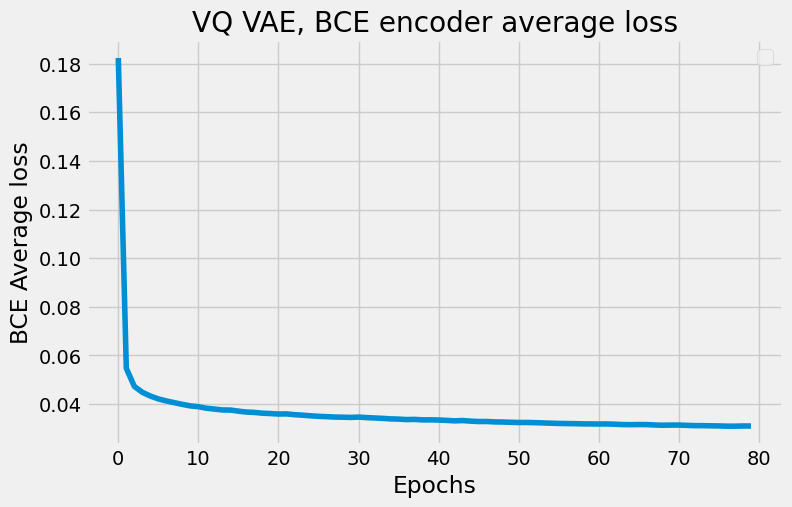

Saved VQ-VAE loss train data to csv
Saved VQ-VAE loss validation data to csv


In [24]:
# display loss values
cms_plots.plot_curve(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="BCE Average loss",
    title="VQ VAE, BCE encoder average loss",
    x_label="Epochs"
)

# Saving train loss data
data_csv = pd.DataFrame(
    {
        "vq_average_loss" : average_loss_train,
        "bce_average_train_loss" : average_loss_train_bce,
        "mse_average_train_loss" : average_loss_train_mse,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_train.csv",index=False)
print("Saved VQ-VAE loss train data to csv")

# Saving validation loss data
data_csv = pd.DataFrame(
    {
        "bce_average_val_loss" : average_loss_values_val,
        "mse_average_val_loss" : average_loss_valid_mse_val,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_val.csv",index=False)
print("Saved VQ-VAE loss validation data to csv")


In [25]:
# Test set for testing using unseen data
model.load_state_dict(torch.load("vqvae.pth"))
model.eval()

bce_loss_values_test = []

patch_display_limit = 6
patches_after_test = []
patches_before_test = []
patches_encodings_test = [] # latent vector

bce_total_value = 0
perplexity_total = 0
test_set_size = len(test_loader)

for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        codebook_test, 
        z_q, 
        perplexity,
        _
    ) = model(patch_test)
    
    perplexity_total += perplexity.item()
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
        patches_encodings_test.append(
            model_tool._tensor_to_numpy(codebook_test)
        )
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(
        patch_test, 
        recon_patch, 
        reduction="mean"
    ).cpu().detach().numpy().item()
    
    bce_total_value += bce_loss
    
bce_loss_average = bce_total_value / test_set_size
perplexity_average = perplexity_total / test_set_size

print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")
print(f"Based on test set (size = {test_set_size}), average codebook perplexity = {perplexity_average:.5f}/{num_embeddings}")

# saving
test_df_frame = pd.DataFrame(
    {
        "average_bce_loss_test" : [bce_loss_average],
        "average_perplexity_test" : [perplexity_average]
    }
)
test_df_frame.to_csv("vqvae_test_loss.csv")
print("Saved VQ-VAE test results")

Based on test set (size = 45), average BCE loss = 0.14407
Based on test set (size = 45), average codebook perplexity = 116.08846/256
Saved VQ-VAE test results


In [26]:
len(patches_before_test)

6

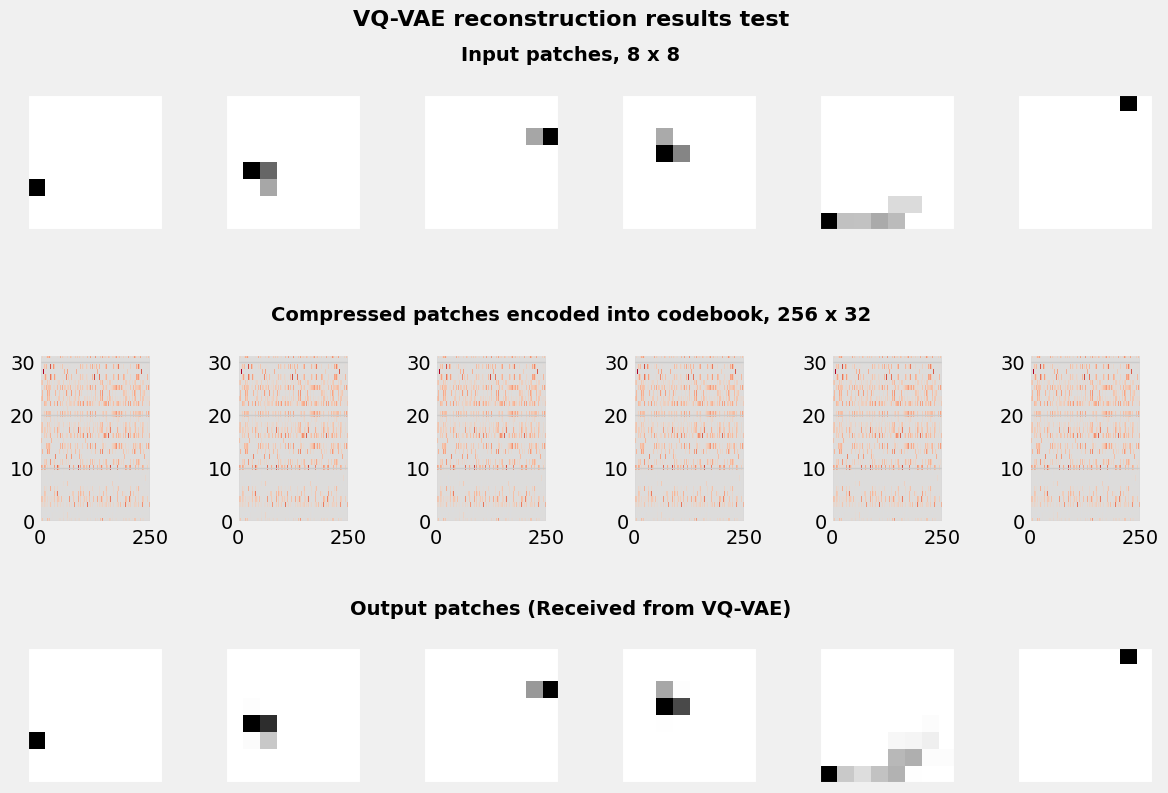

In [27]:
# Test dataset plotting part
patch_rows = [
    (patches_before_test, "Input patches, 8 x 8"),
    (patches_encodings_test, f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"),
    (patches_after_test, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results test", include_codebook=True)

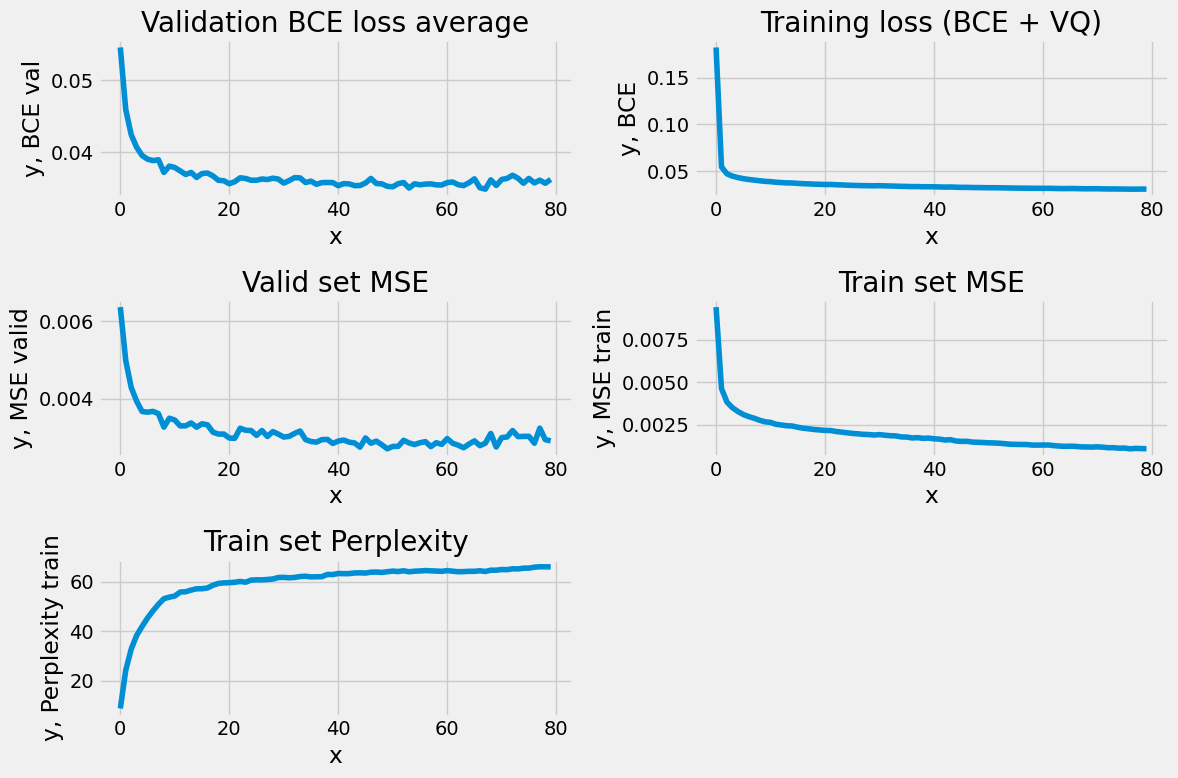

In [28]:
values_to_plot = [
    (list(range(len(average_loss_values_val))), average_loss_values_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE + VQ)", "BCE"),
    (list(range(len(average_loss_valid_mse_val))), average_loss_valid_mse_val, "Valid set MSE", "MSE valid"),
    (list(range(len(average_loss_train_mse))), average_loss_train_mse, "Train set MSE", "MSE train"),
    (list(range(len(average_perplexity_train))), average_perplexity_train, "Train set Perplexity", "Perplexity train"),
]

cms_plots.plot_curves(values_to_plot)
